In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("C:\\Users\\User\\churn-predictor\\data\\telco_churn_clean.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [3]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features:", X.shape)
print("Target distribution:\n", y.value_counts())

Features: (7032, 19)
Target distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [4]:
# Numerical columns — will be scaled
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Categorical columns — will be one-hot encoded
cat_cols = [col for col in X.columns if col not in num_cols]

print("Numerical:", num_cols)
print("\nCategorical:", cat_cols)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← preserves 73/27 class ratio in both splits
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate: ", y_test.mean().round(3))

Train size: (5625, 19)
Test size:  (1407, 19)

Train churn rate: 0.266
Test churn rate:  0.266


In [7]:
# Numerical: just scale
num_transformer = StandardScaler()

# Categorical: one-hot encode, drop first to avoid dummy trap
cat_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

# Combine both
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [8]:
# Logistic model 
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
print("✅ Logistic Regression trained")

✅ Logistic Regression trained


In [9]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=" * 45)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 45)
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC Score: 0.8353


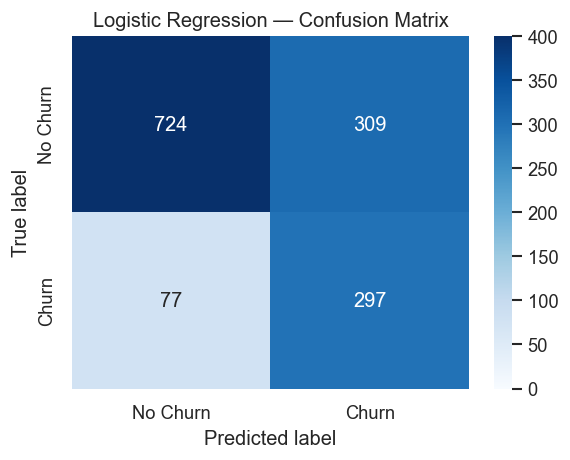

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    vmin=0, vmax=400,      # ← same fix as RF
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig("../data/lr_confusion_matrix.png")
plt.show()

In [11]:
# Random Forest model
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("✅ Random Forest trained")

✅ Random Forest trained


In [12]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=" * 45)
print("RANDOM FOREST — Classification Report")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8179


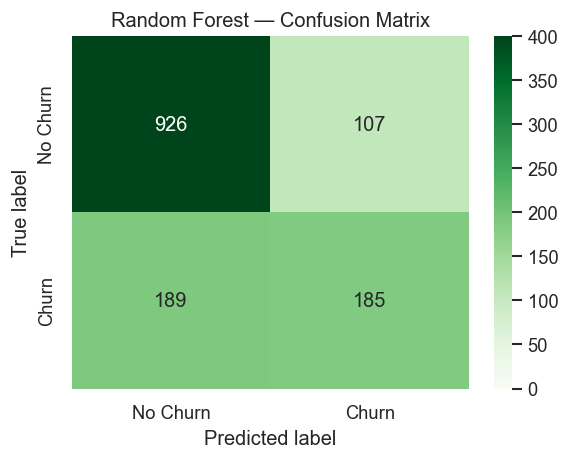

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True, fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    vmin=0, vmax=400,      # ← force same color scale for all cells
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("../data/rf_confusion_matrix.png")
plt.show()

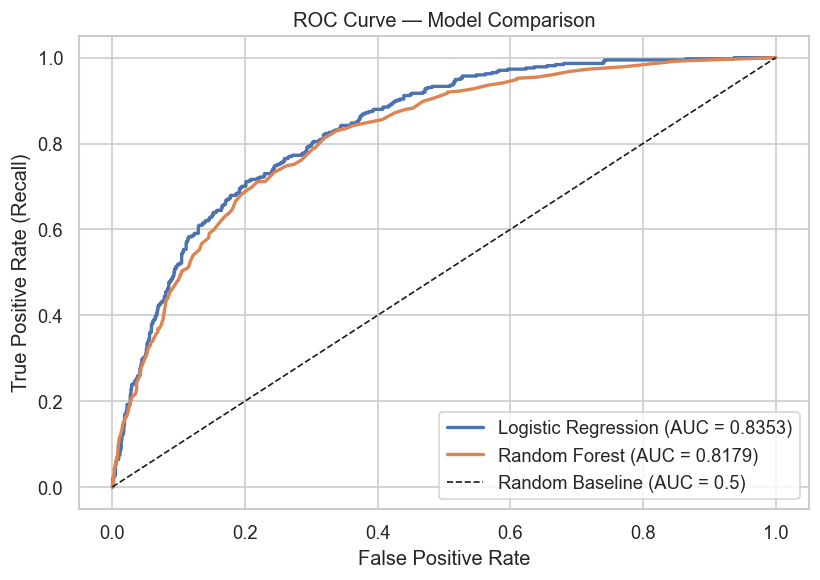

In [20]:
# ROC Curve

fig, ax = plt.subplots(figsize=(7, 5))

for name, y_prob in [("Logistic Regression", y_prob_lr), ("Random Forest", y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Baseline (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("../data/roc_curve_comparison.png")
plt.show()

In [21]:
import joblib

joblib.dump(lr_pipeline, "../data/churn_model.pkl")
print("✅ Model saved to data/churn_model.pkl")

✅ Model saved to data/churn_model.pkl
